# Image-based analysis (experimental)

Although FRAP primarily operates on the visibility plane, there are situations where visibility analysis is not suitable. For instance, if a disk exhibits significant azimuthal asymmetry, azimuthal averaging is not adequate. In such cases, FRAP can also process radial intensity profiles. While this function has not been extensively tested, we demonstrate its usage in this notebook.

The basic usage is the same as the [normal procedure](tutorial_1.ipynb).

In [1]:
import frap
import numpyro
import pickle
import dsharp_opac
import jax.numpy as jnp

In [2]:
numpyro.set_host_device_count(10)

In this example, we use a mock data set, and assume a cut along the major axis. 

In [3]:
bands = [ 'band3', 'band6' ]
data = {
    'band3' : 'data_band3.pkl',
    'band6' : 'data_band6.pkl'
}

In [4]:
obs = {}

for band in bands:
    with open(data[band], 'rb') as f:
        obs[band] = pickle.load(f)
        

The structure of the data should be like this.

In [5]:
obs['band6'].keys()

dict_keys(['r', 'Tb', 'Cov', 'nu'])

The unit of Tb should be brightness temprature. Cov is the covariance matrix of the noise.

Text(0, 0.5, 'Tb')

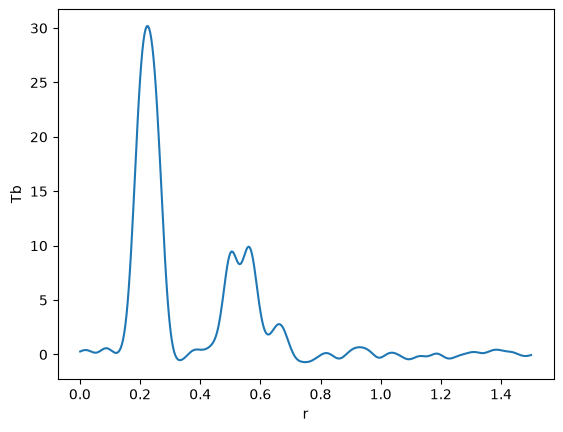

In [7]:
import matplotlib.pyplot as plt
plt.plot( obs['band6']['r'], obs['band6']['Tb'] )
plt.xlabel('r')
plt.ylabel('Tb')

Those settings are identical to the visibility-based analysis

In [8]:
dust_opacity = jnp.load(dsharp_opac.get_datafile('default_opacities_smooth.npz'))

disk = frap.model( incl= 6.0,
                     r_out = 1.3,
                     N_GP = 130,
                     flux_uncert = True )

D = 114.9 # pc

disk.set_parameter('log10_T', 
                   free = False, 
                   profile = lambda r: jnp.log10(77.0*(r*D/10)**(-0.5)) )


disk.set_parameter('q', 
                   free = False, 
                   profile = lambda r: 3.5 )


lengthscale = 0.03

disk.set_parameter('log10_Sigma_d', free = True,
                                    bounds = ( -6.0, 3.0 ), 
                                    lengthscale = lengthscale)

disk.set_parameter('log10_a_max', free = True, 
                                    bounds =  ( -2.0, 2.0 ),
                                    lengthscale = lengthscale)


Then you can use `set_radialprofile()` to set your radial profile. Here you also have to give the covariance matrix.

In [9]:
f_s = { 'band3': 0.025, 'band6': 0.05 }
f_mean = { 'band3': 1.0, 'band6': 1.0 }
    
for band in bands:
    disk.set_radialprofile( band = band,
                            r = [obs[band]['r']],
                            Tb = [obs[band]['Tb']],
                            nu = [obs[band]['nu']],
                            Nch = 1,
                            f_s = f_s[band],
                            f_mean = f_mean[band],
                            FWHM = 0.05, 
                            Cov = [obs[band]['Cov']] )

Remaining part is the same as before!

In [25]:
disk.set_opacity( opac_dict = dust_opacity )

In [26]:
inference = frap.inference(disk)

In [27]:
num_warmup = 500
num_samples = 500
num_chains = 10

posterior = inference.MCMC( num_warmup = num_warmup, 
                            num_samples = num_samples,
                            num_chains = num_chains )


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                            mean       std    median      5.0%     95.0%     n_eff     r_hat
       g_f_scale_band3     -0.72      0.75     -0.72     -1.97      0.53    435.13      1.02
       g_f_scale_band6     -1.23      0.27     -1.23     -1.70     -0.79    538.59      1.02
  g_log10_Sigma_d_z[0]     -1.06      0.57     -0.95     -1.91     -0.23    353.63      1.02
  g_log10_Sigma_d_z[1]     -0.59      0.83     -0.55     -1.97      0.73     63.19      1.07
  g_log10_Sigma_d_z[2]     -0.57      0.82     -0.56     -1.93      0.77    208.23      1.04
  g_log10_Sigma_d_z[3]     -0.19      0.88     -0.20     -1.73      1.14    147.43      1.06
  g_log10_Sigma_d_z[4]      0.05      0.96      0.06     -1.46      1.69     53.61      1.08
  g_log10_Sigma_d_z[5]      0.05      0.91      0.07     -1.43      1.52     64.68      1.07
  g_log10_Sigma_d_z[6]     -0.21      0.94     -0.17     -1.71      1.37     85.47      1.10
  g_log10_Sigma_d_z[7]     -0.36      0.85     -0.37     -1.77      0

In [28]:
plotter = frap.plot( posterior )

saved keys:  dict_keys(['warmup_f', 'posterior_f', 'warmup_g', 'posterior_g'])


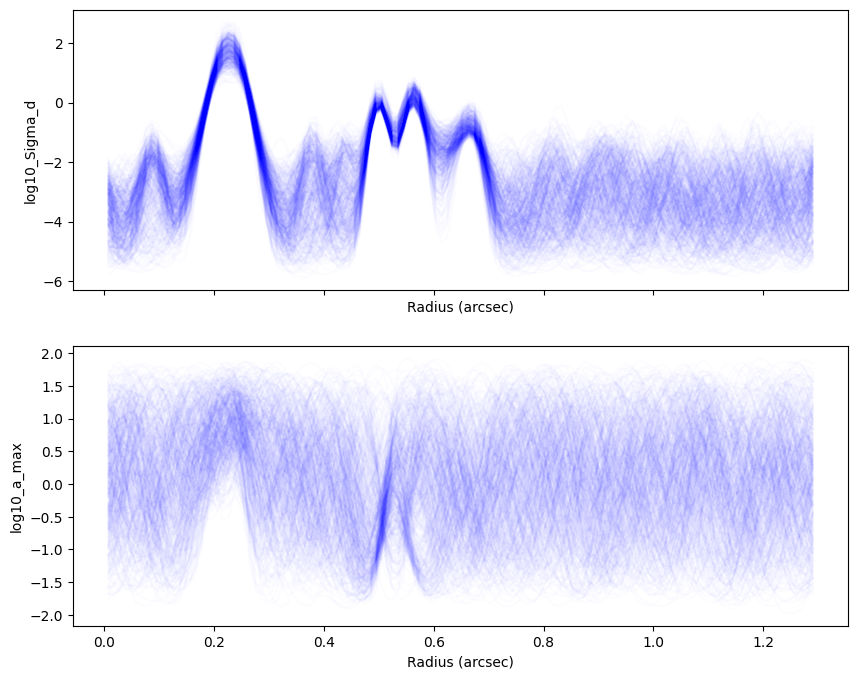

In [32]:
plotter.sample_paths( 'posterior_f', nskip = 10, plot_kwargs = { 'alpha' : 0.01, 'color' : 'b' } )


